# Basal drag — horizontal plane vs isotherm

Compare the **horizontal force from shear (deviatoric) stress** on two surfaces:

1. **Horizontal plane** at fixed depth $z_\mathrm{target}$ (default 100 km). Outward normal $\hat n = (0,1)$, horizontal traction $t_x = \sigma_{zx} = \tau_{zx}$. Integrand per $dx$: $\tau_{zx}$.
2. **Isotherm** $z = z_\mathrm{iso}(x)$, picked so it intersects $z_\mathrm{target}$ at the trench. Outward normal of the lithosphere $\hat n = (-m, 1)/\sqrt{1+m^2}$ with $m = dz_\mathrm{iso}/dx$. Full horizontal traction is $t_x = (-m\sigma_{xx} + \sigma_{zx})/\sqrt{1+m^2}$, which splits into a **pressure** part $pm/\sqrt{1+m^2}$ (carries the lithostatic load) and a **deviatoric** part $(\tau_{zx} - m\tau_{xx})/\sqrt{1+m^2}$. Drop the pressure part. Multiply by $ds = \sqrt{1+m^2}\,dx$ and the √ cancels, giving integrand per $dx$: $\tau_{zx} - m\tau_{xx}$.

Both integrands have units of Pa and act as integrands of horizontal force per $dx$, so they are directly comparable. On a flat surface ($m=0$) the iso integrand reduces to $\tau_{zx}$, matching the flat case.

**Why not just integrate the tangential stress $\tau_{\xi\eta}$ along the iso?** That gives a slab-tangential force resultant, not a horizontal one. Projecting it horizontally as $\tau_{\xi\eta}\cos\theta$ still misses the contribution of $\tau_{\eta\eta}$ which projects horizontally as $-\tau_{\eta\eta}\sin\theta$ on a tilted surface. The two combined recover $(\tau_{zx} - m\tau_{xx})/\sqrt{1+m^2}$ — i.e. the formulation here.

Setup mirrors `fluidity_single_step.ipynb` and `fluidity_slab_normal_FD.ipynb`.

**Why this matters to the narrative.** Basal drag ($F_B$) plays a resisting role in the trailing-plate balance; the standing question is whether it is ever *important*. On the wavelength of the trench topography it is always second order — this notebook quantifies the traction that claim rests on.

## 1. Setup & imports

In [1]:
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

`DEPTH_TARGET` is the horizontal-plane depth and the depth at which the chosen isotherm crosses the trench.

In [2]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY      = 'WAL'
TIMESTEP_INDEX = 10
DEPTH_TARGET   = 100_000.0   # m  — horizontal plane depth & isotherm depth at trench

DX        = 500.0           # horizontal integrations don't need fine resolution
Z_MAX     = 200_000.0
Y_SURFACE = 2_900_000.0

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
i = TIMESTEP_INDEX if TIMESTEP_INDEX >= 0 else len(pvtu_files) + TIMESTEP_INDEX
ff = pvtu_files[i]
print(f"Model {MODEL_KEY!r} timestep {i}: {ff.split('/')[-1]}")

# === Mirror flag ============================================================
# When True, every extracted field is mirrored along x so that subduction
# matches the MDOODZ convention (subducting plate on the right, vx < 0).
# Derived constants below propagate this choice to direction-dependent code.
MIRROR_X        = True
SUBDUCTING_SIDE = "right" if MIRROR_X else "left"
SEAWARD_SIGN    = +1     if MIRROR_X else -1   # use as: x_trench + SEAWARD_SIGN * offset_metres
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")


Model 'WAL' timestep 10: subduction_with_LM_10.pvtu
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


## 3. Helpers

In [3]:
import sys
from pathlib import Path
# cerpa_helpers lives in notebooks/, one level above further_analysis/
_helpers_dir = str(Path("..").resolve())
if _helpers_dir not in sys.path:
    sys.path.insert(0, _helpers_dir)

import sys, os
_r = os.getcwd()
while not os.path.isdir(os.path.join(_r, 'scripts')) and os.path.dirname(_r) != _r:
    _r = os.path.dirname(_r)
if os.path.join(_r, 'scripts') not in sys.path:
    sys.path.insert(0, os.path.join(_r, 'scripts'))
from cerpa_helpers import (
    make_field_extractor,
    mirror_fields_in_x,
    pick_trench_3step,
    find_first_isostatic_column,
    find_ridge_x,
    col_avg,
    norm01,
    load_records,
)


## 4. Load PVTU and build the regular grid

Need vertical extent below `DEPTH_TARGET` so the isotherm has room to dip; here `Z_MAX = 200 km`.

In [4]:
vtk_data = pv.read(ff)
t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / 31_557_600.0

# === Coordinate convention =================================================
# Model frame: (x, y) with y vertical UP.  Notebook frame: (x, z) with
# z = Y_SURFACE - y, depth positive DOWN.  The reflection y -> -z flips
# off-diagonal stress components: sigma_zx_zdown = -sigma_xy_yup.  We apply
# that flip HERE at extraction so all downstream code is in z-down convention.
vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]   # sigma_zx_zdown = -sigma_xy_yup
vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
vtk_data.point_data['vx']  = vel[:, 0]
vtk_data.point_data['vy']  = vel[:, 1]

x_min, x_max, _, _, _, _ = vtk_data.bounds
nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
x = x_min + (np.arange(nx) + 0.5) * DX
z = (np.arange(nz) + 0.5) * DX
X, Z = np.meshgrid(x, z, indexing='xy')
Y = Y_SURFACE - Z
grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
interp = grid.sample(vtk_data)
nx_pv, nz_pv, _ = interp.dimensions
valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)

p   = get_field('p')
txx = get_field('txx')
tzz = get_field('tzz')
txz = get_field('txz')
T   = get_field('T')
fs  = get_field('fs')
vx  = get_field('vx')
vz  = -get_field('vy')

# === Apply x-mirror ==========================================================
if MIRROR_X:
    p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
    print('(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)')

print(f'grid: {p.shape}  x in [{x[0]/1e3:.0f}, {x[-1]/1e3:.0f}] km, z in [{z[0]/1e3:.2f}, {z[-1]/1e3:.2f}] km, dx = {DX/1e3:.2f} km')


(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)
grid: (400, 15999)  x in [0, 7999] km, z in [0.25, 199.75] km, dx = 0.50 km


## 5. Trench identification

In [5]:
x_trench, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000, Wv_km=800, Wp3_km=800,
    smooth_km=40, subducting_side=SUBDUCTING_SIDE,
)
tindx = int(np.argmin(np.abs(x - x_trench)))
print(f'Trench at x = {x_trench/1e3:.1f} km (index {tindx})')


Trench at x = 4440.2 km (index 8880)


## 6. Pick isotherm and trace its depth $z_\mathrm{iso}(x)$

Sample $T$ at $(x_\mathrm{trench},\,z_\mathrm{target})$ and use that value as `T_ISO`. Then for each $x$, interpolate the depth where $T(x,z) = T_\mathrm{iso}$.

In [6]:
iz_target = int(np.argmin(np.abs(z - DEPTH_TARGET)))
z_target  = float(z[iz_target])
T_ISO     = float(T[iz_target, tindx])
print(f'Target depth z_target = {z_target/1e3:.2f} km')
print(f'T(x_trench, z_target)  = {T_ISO:.1f} °C   →  using as T_ISO')

# Trace isotherm depth across all x
z_iso = np.full(x.shape, np.nan)
for ix in range(len(x)):
    Tcol = T[:, ix]
    good = np.isfinite(Tcol)
    if good.sum() < 2:
        continue
    Tg, zg = Tcol[good], z[good]
    if not np.all(np.diff(Tg) > 0):
        # T must be monotone in z within the lithosphere; clip to monotone-increasing prefix
        end = np.argmax(np.diff(Tg) <= 0) if np.any(np.diff(Tg) <= 0) else len(Tg) - 1
        if end < 2:
            continue
        Tg, zg = Tg[:end+1], zg[:end+1]
    if T_ISO <= Tg.min() or T_ISO >= Tg.max():
        continue
    z_iso[ix] = np.interp(T_ISO, Tg, zg)

valid_iso = np.isfinite(z_iso)
n_valid   = int(valid_iso.sum())
print(f'isotherm traced at {n_valid} / {len(x)} columns ({100*n_valid/len(x):.1f}%)')
print(f'  z_iso at trench: {z_iso[tindx]/1e3:.2f} km   (target: {z_target/1e3:.2f} km — should match by construction)')

Target depth z_target = 99.75 km
T(x_trench, z_target)  = 1475.6 °C   →  using as T_ISO


isotherm traced at 15798 / 15999 columns (98.7%)
  z_iso at trench: 99.75 km   (target: 99.75 km — should match by construction)


## 7. Sample stresses on each surface and form the integrands

- Horizontal: $\tau_{zx}(x, z_\mathrm{target})$ — directly from the grid row.
- Isotherm: $(\tau_{zx} - m\,\tau_{xx})$ at $(x, z_\mathrm{iso}(x))$, with $m = dz_\mathrm{iso}/dx$ from `np.gradient` over the valid region.

Both quantities have units of Pa and are integrands of horizontal force per $dx$, so they are directly comparable.

In [7]:
# Slope of the isotherm. Compute on valid stretch only, then map back.
m_iso = np.full(x.shape, np.nan)
x_v   = x[valid_iso]
z_v   = z_iso[valid_iso]
m_v   = np.gradient(z_v, x_v)
m_iso[valid_iso] = m_v

# τ_zx on horizontal plane
txz_flat = txz[iz_target, :]

# Stresses on isotherm via interpolator
def make_interp(field):
    return RegularGridInterpolator((z, x), field, bounds_error=False, fill_value=np.nan)

ftxx = make_interp(txx)
ftxz = make_interp(txz)

txx_iso = np.full(x.shape, np.nan)
txz_iso = np.full(x.shape, np.nan)
pts = np.column_stack([z_iso[valid_iso], x[valid_iso]])
txx_iso[valid_iso] = ftxx(pts)
txz_iso[valid_iso] = ftxz(pts)

# Pointwise integrands of horizontal force per dx (deviatoric only — pressure dropped)
tx_horiz_flat = txz_flat                          # τ_zx on horizontal plane
tx_horiz_iso  = txz_iso - m_iso * txx_iso         # (τ_zx - m τ_xx) on isotherm

# Quick sanity at trench
print(f'at x_trench:')
print(f'  τ_zx on horizontal (z={z_target/1e3:.0f} km): {tx_horiz_flat[tindx]/1e6:+.3f} MPa')
print(f'  τ_zx - m τ_xx on isotherm           : {tx_horiz_iso[tindx]/1e6:+.3f} MPa')
print(f'  m = dz_iso/dx at trench             : {m_iso[tindx]:+.4f}  (dip = {np.rad2deg(np.arctan(m_iso[tindx])):+.2f}°)')

at x_trench:
  τ_zx on horizontal (z=100 km): +0.407 MPa
  τ_zx - m τ_xx on isotherm           : +0.375 MPa
  m = dz_iso/dx at trench             : -0.1348  (dip = -7.67°)


## 8. Plot — geometry and integrand comparison

/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_98447/300090202.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


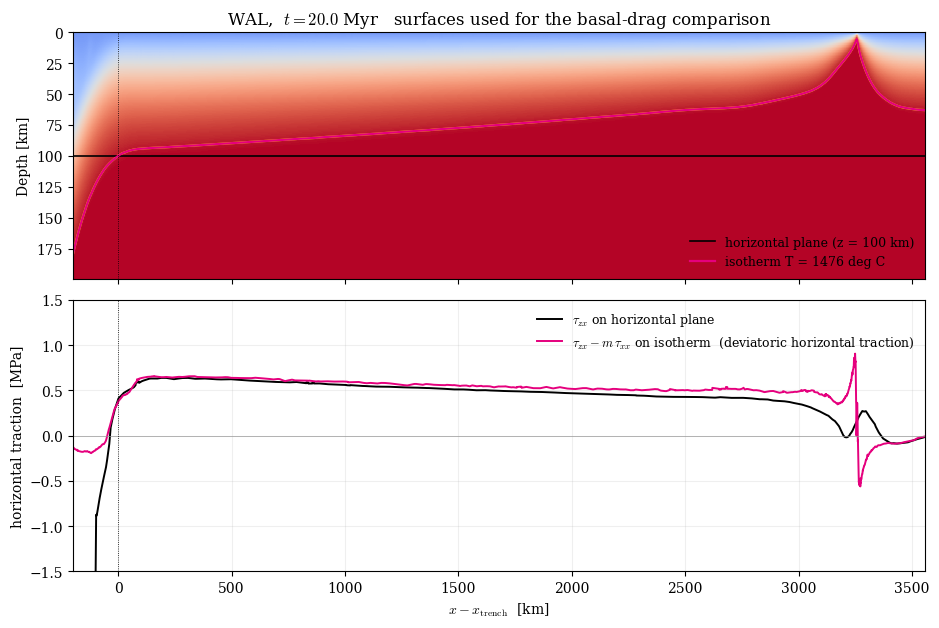

In [8]:
# After x-mirror, trailing plate is on the right, so the visible window
# extends from a bit before the trench (slab side) out to the right edge.
X_LO_KM = -200                            # km on the slab side
X_HI_KM = (x[-1] - x_trench) * 1e-3           # right edge of model, trench-relative

xkm_rel = (x - x_trench) * 1e-3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw=dict(height_ratios=[1, 1.1], hspace=0.08))

im = ax1.pcolormesh(xkm_rel, z*1e-3, T, cmap='coolwarm', shading='auto', vmin=0, vmax=1500)
ax1.contour(xkm_rel, z*1e-3, T, levels=[T_ISO], colors='gold', linewidths=1.6)
ax1.axhline(z_target*1e-3, color='k', lw=1.2, ls='-', label=f'horizontal plane (z = {z_target/1e3:.0f} km)')
ax1.plot(xkm_rel[valid_iso], z_iso[valid_iso]*1e-3, color='#E5007D', lw=1.6,
         label=f'isotherm T = {T_ISO:.0f} deg C')
ax1.axvline(0, color='k', lw=0.6, ls=':')
ax1.invert_yaxis()
ax1.set_xlim(X_LO_KM, X_HI_KM)
ax1.set_ylim(z[-1]*1e-3, 0)
ax1.set_ylabel('Depth [km]')
ax1.legend(loc='lower right', frameon=False, fontsize=9)
ax1.set_title(f'{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr   surfaces used for the basal-drag comparison')

ax2.plot(xkm_rel, tx_horiz_flat*1e-6, 'k-', lw=1.4,
         label=r'$\tau_{zx}$ on horizontal plane')
ax2.plot(xkm_rel, tx_horiz_iso *1e-6, color='#E5007D', lw=1.4,
         label=r'$\tau_{zx} - m\,\tau_{xx}$ on isotherm  (deviatoric horizontal traction)')
ax2.axhline(0, color='0.6', lw=0.5)
ax2.axvline(0, color='k', lw=0.6, ls=':')
ax2.set_xlabel(r'$x - x_\mathrm{trench}$  [km]')
ax2.set_ylabel(r'horizontal traction  [MPa]')
ax2.legend(loc='upper right', frameon=False, fontsize=9)
ax2.grid(alpha=0.2)
ax2.set_xlim(X_LO_KM, X_HI_KM)
ax2.set_ylim(-1.5, 1.5)

fig.tight_layout()
figures_dir = Path('../../figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'basal_drag_iso_vs_flat_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 9. Integrated comparison

Integrate both integrands over a configurable $x$-range. Default: from a chosen $x_\mathrm{lo}$ out to the trench (subducting plate).

In [9]:
# Integration window — from the trench out into the trailing plate (rightward
# in the mirrored frame).  Use SEAWARD_SIGN so the same cell works either way.
WINDOW_KM = 1750                       # length of the trailing-plate window
X_INT_LO  = min(x_trench, x_trench + SEAWARD_SIGN * WINDOW_KM * 1e3)
X_INT_HI  = max(x_trench, x_trench + SEAWARD_SIGN * WINDOW_KM * 1e3)

mask_int = (x >= X_INT_LO) & (x <= X_INT_HI) & np.isfinite(tx_horiz_iso)
x_int = x[mask_int]
F_flat = np.trapz(tx_horiz_flat[mask_int], x_int)
F_iso  = np.trapz(tx_horiz_iso [mask_int], x_int)

print(f'Integration window: x in [{X_INT_LO/1e3:.0f}, {X_INT_HI/1e3:.0f}] km')
print(f'  F_B  on horizontal plane (z = {z_target/1e3:.0f} km):  {F_flat*1e-12:+8.4f}  TN/m   = int tau_zx dx')
print(f'  F_B  on isotherm (T = {T_ISO:.0f} deg C):              {F_iso *1e-12:+8.4f}  TN/m   = int (tau_zx - m tau_xx) dx')
if F_flat != 0:
    print(f'  difference: {(F_iso - F_flat)*1e-12:+.4f} TN/m   ({(F_iso/F_flat - 1)*100:+.1f} %)')


Integration window: x in [4440, 6190] km
  F_B  on horizontal plane (z = 100 km):   +0.9894  TN/m   = int tau_zx dx
  F_B  on isotherm (T = 1476 deg C):               +1.0400  TN/m   = int (tau_zx - m tau_xx) dx
  difference: +0.0506 TN/m   (+5.1 %)
